# 01 - Explorar Catalysis Hub

Uma unica query GraphQL ao Catalysis Hub retornando 10 reacoes de HER (`0.5 H2(g) + * -> H*`) e reconstrucao de uma estrutura `ase.Atoms` valida.

In [1]:
import logging

import pandas as pd

from ingest import fetch_reactions, reaction_to_atoms

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

## Uma query: 10 reacoes de HER

Filtro `products="H"` seleciona reacoes cujo produto contem H adsorvido.

In [2]:
nodes, page_info = fetch_reactions(first=10, products="H")
print(f"reacoes retornadas: {len(nodes)}  | hasNextPage={page_info['hasNextPage']}")

df = pd.DataFrame(
    [
        {
            "id": n["id"],
            "equation": n["Equation"],
            "composition": n["chemicalComposition"],
            "facet": n["facet"],
            "delta_G_H": n["reactionEnergy"],
            "coverages": n["coverages"],
            "sites": n["sites"],
        }
        for n in nodes
    ]
)
df

INFO her_gnn.ingest: fetched 10 reactions (hasNextPage=True)


reacoes retornadas: 10  | hasNextPage=True


,id,equation,composition,facet,delta_G_H,coverages,sites
0,UmVhY3Rpb246NDU2NTc0,0.5H2(g) + * -> H*,Cu36,111,0.067899,None,{}
1,UmVhY3Rpb246NDU2NTc2,0.5H2(g) + * -> H*,Ru36,0001,-0.492011,None,{}
2,UmVhY3Rpb246NDU2NTc4,0.5H2(g) + * -> H*,Ag27,111,0.373594,None,{}
3,UmVhY3Rpb246NDU2NTgz,0.5H2(g) + * -> H*,Ag36,100,0.584871,None,{}
4,UmVhY3Rpb246NDU2NTg2,0.5H2(g) + * -> H*,Ni27,111,-0.379822,None,{}
5,UmVhY3Rpb246NDU2NTg4,0.5H2(g) + * -> H*,Rh27,111,-0.281019,None,{}
6,UmVhY3Rpb246NDU2NTkw,0.5H2(g) + * -> H*,Au27,111,0.373724,None,{}
7,UmVhY3Rpb246NDU2NTk0,0.5H2(g) + * -> H*,Au36,100,0.328439,None,{}
8,UmVhY3Rpb246NDU2NTk4,0.5H2(g) + * -> H*,Co36,0001,-0.477633,None,{}
9,UmVhY3Rpb246NDU2NjAw,0.5H2(g) + * -> H*,Pt27,111,-0.277981,None,{}


## Reconstruir uma estrutura `ase.Atoms`

Cada reacao guarda em `reactionSystems` o slab nu (`star`), o gas de referencia (`H2gas`) e o slab com H adsorvido (`Hstar`). `reaction_to_atoms` extrai o slab adsorvido e anexa metadados em `atoms.info`.

In [3]:
atoms = reaction_to_atoms(nodes[0])

print(atoms)
print("formula:    ", atoms.get_chemical_formula())
print("n_atoms:    ", len(atoms))
print("pbc:        ", atoms.pbc)
print("cell (A):   ", atoms.cell.lengths().round(3))
print("info:       ", atoms.info)

Atoms(symbols='Cu36H', pbc=True, cell=[[7.797419751327892, 2.6020852139652106e-18, 0.0], [3.898709875663943, 6.752763588620494, 0.0], [1.2995699585546543, 0.7503070654022808, 21.221888556725144]])
formula:     HCu36
n_atoms:     37
pbc:         [ True  True  True]
cell (A):    [ 7.797  7.797 21.275]
info:        {'id': 'UmVhY3Rpb246NDU2NTc0', 'delta_G_H': 0.06789873234083643, 'source': 'catalysis_hub', 'composition': 'Cu36', 'facet': '111'}


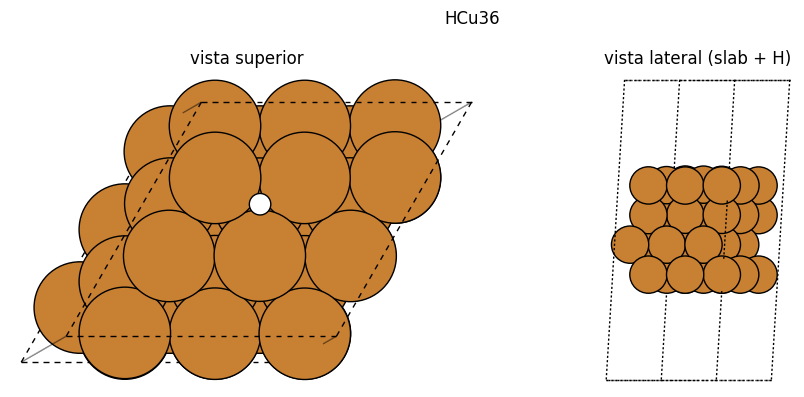

In [4]:
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_atoms(atoms, axes[0], rotation="0x,0y,0z")
axes[0].set_title("vista superior")
plot_atoms(atoms, axes[1], rotation="-90x,0y,0z")
axes[1].set_title("vista lateral (slab + H)")
for ax in axes:
    ax.set_axis_off()
fig.suptitle(atoms.get_chemical_formula())
plt.tight_layout()
plt.show()

## Sanidade: reconstruir as 10

Confirma que todas as 10 reacoes da query produzem `ase.Atoms` validos.

In [5]:
reconstruidas = sum(reaction_to_atoms(n) is not None for n in nodes)
print(f"reconstruidas: {reconstruidas}/{len(nodes)}")

reconstruidas: 10/10
